In [1]:
# Import seaborn and apply its plotting styles
import seaborn as sns
sns.set(font_scale=2, style="white")

# import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
# set plotting size parameter
plt.rcParams['figure.figsize'] = (17, 7)


import pandas as pd
import numpy as np

# Statmodels & patsy
import patsy
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

In [2]:
training_data = pd.read_csv('../Data_sources/playground-series-Forecasting Sticker Sales/train.csv')
testing_data = pd.read_csv('../Data_sources/playground-series-Forecasting Sticker Sales/test.csv')
sample_submission = pd.read_csv('../Data_sources/playground-series-Forecasting Sticker Sales/sample_submission.csv')

In [3]:
testing_data.head()

,id,date,country,store,product
0,230130,2017-01-01,Canada,Discount Stickers,Holographic Goose
1,230131,2017-01-01,Canada,Discount Stickers,Kaggle
2,230132,2017-01-01,Canada,Discount Stickers,Kaggle Tiers
3,230133,2017-01-01,Canada,Discount Stickers,Kerneler
4,230134,2017-01-01,Canada,Discount Stickers,Kerneler Dark Mode


In [4]:
training_data.shape

(230130, 6)

In [5]:
print(training_data.columns)
training_data.head()

Index(['id', 'date', 'country', 'store', 'product', 'num_sold'], dtype='object')


,id,date,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0


In [6]:
print(training_data.value_counts('store'))
print(training_data.value_counts('country'))
print(training_data.value_counts('product'))

store
Discount Stickers       76710
Premium Sticker Mart    76710
Stickers for Less       76710
dtype: int64
country
Canada       38355
Finland      38355
Italy        38355
Kenya        38355
Norway       38355
Singapore    38355
dtype: int64
product
Holographic Goose     46026
Kaggle                46026
Kaggle Tiers          46026
Kerneler              46026
Kerneler Dark Mode    46026
dtype: int64


In [7]:
null_training = training_data.loc[training_data['num_sold'].isnull()]

training_data = training_data.dropna()

<Axes: xlabel='country', ylabel='Count'>

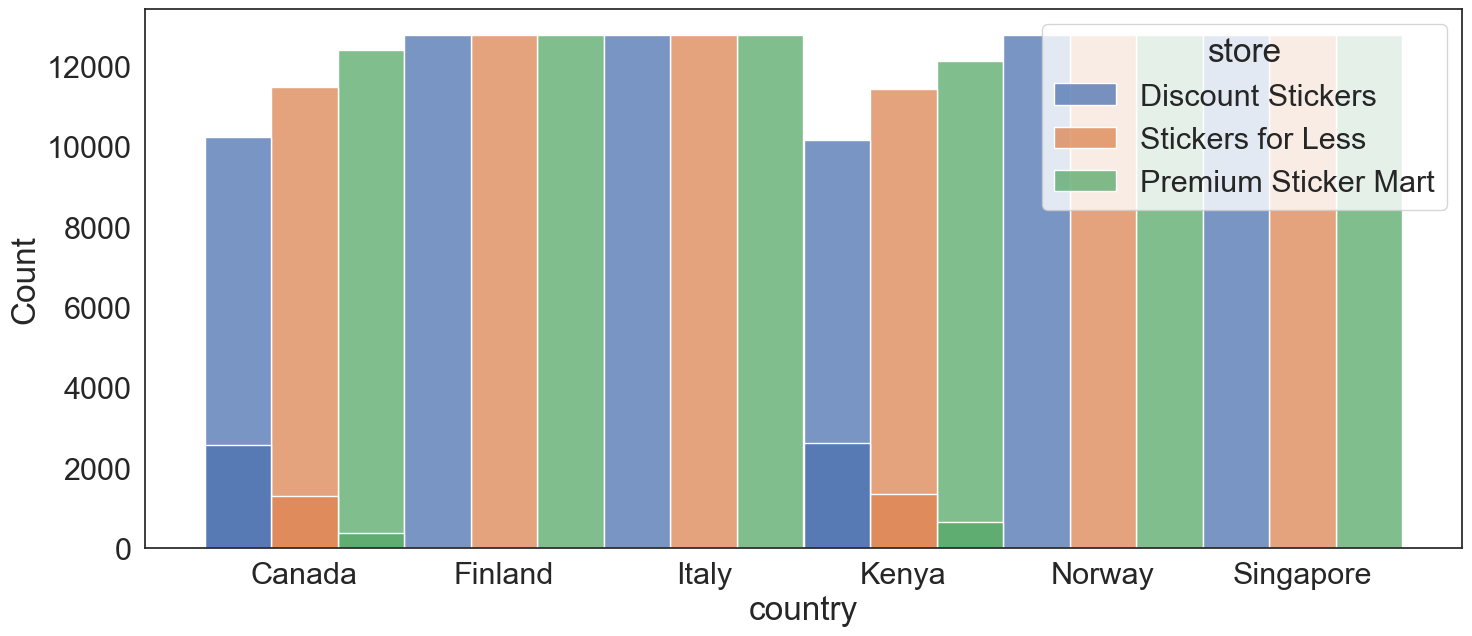

In [8]:
sns.histplot(data = training_data, x = 'country', hue = 'store', multiple = 'dodge')
sns.histplot(data = null_training, x = 'country', hue = 'store', multiple = 'dodge')

In this graph we can see that Candada and Kenya are missing equivalent ratios of sticker sold counts. This should be taken into account when building a model. With the possible need to normalize the data to have more accurate predictions.



In [9]:
# create Dummy variables
dummy_set = ['store','country','product']

# Create dummy sets
training_dummy = training_data[dummy_set]
testing_dummy = testing_data[dummy_set]

# get the dummy variables
training_dummy = pd.get_dummies(training_dummy)
testing_dummy = pd.get_dummies(testing_dummy)

#Drop the variables in the testing and training set
training_data.drop(columns=dummy_set, errors='ignore', inplace=True)
testing_data.drop(columns=dummy_set, errors='ignore', inplace=True)

# Join the data set with its dummy variables:
training_data = training_data.join(training_dummy)
testing_data = testing_data.join(testing_dummy)

In [10]:
training_data.isnull().sum()

id                            0
date                          0
num_sold                      0
store_Discount Stickers       0
store_Premium Sticker Mart    0
store_Stickers for Less       0
country_Canada                0
country_Finland               0
country_Italy                 0
country_Kenya                 0
country_Norway                0
country_Singapore             0
product_Holographic Goose     0
product_Kaggle                0
product_Kaggle Tiers          0
product_Kerneler              0
product_Kerneler Dark Mode    0
dtype: int64

In [11]:
null_training.describe()

,id,num_sold
count,8871.000000,0.0
mean,106725.236276,NaN
std,68781.316085,NaN
min,0.000000,NaN
25%,45562.500000,NaN
50%,102690.000000,NaN
75%,169922.500000,NaN
max,230085.000000,NaN


In [12]:
training_data.describe()

,id,num_sold,store_Discount Stickers,store_Premium Sticker Mart,store_Stickers for Less,country_Canada,country_Finland,country_Italy,country_Kenya,country_Norway,country_Singapore,product_Holographic Goose,product_Kaggle,product_Kaggle Tiers,product_Kerneler,product_Kerneler Dark Mode
count,221259.000000,221259.000000,221259.000000,221259.000000,221259.000000,221259.000000,221259.000000,221259.000000,221259.000000,221259.000000,221259.000000,221259.000000,221259.000000,221259.000000,221259.000000,221259.000000
mean,115398.848472,752.527382,0.323291,0.342061,0.334649,0.154159,0.173349,0.173349,0.152446,0.173349,0.173349,0.168219,0.208019,0.208019,0.207729,0.208014
std,66315.365084,690.165445,0.467734,0.474401,0.471869,0.361102,0.378549,0.378549,0.359453,0.378549,0.378549,0.374062,0.405891,0.405891,0.405683,0.405888
min,1.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,58160.500000,219.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,115552.000000,605.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,172688.500000,1114.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,230129.000000,5939.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


---------------------
## First Model

- Set the prediction target : number of stickers sold.
- Create the training features.
- Build model.
    - definde the type of model.
    - fit the model
    - Predict
    - Evaluate

In [13]:
training_features = ['store_Discount Stickers',
       'store_Premium Sticker Mart', 'store_Stickers for Less',
       'country_Canada', 'country_Finland', 'country_Italy', 'country_Kenya',
       'country_Norway', 'country_Singapore', 'product_Holographic Goose',
       'product_Kaggle', 'product_Kaggle Tiers', 'product_Kerneler',
       'product_Kerneler Dark Mode']

In [14]:
# Create the prediction variable and input variables
y = training_data.num_sold

X = training_data[training_features]


In [15]:
# Define model
training_model = DecisionTreeRegressor(random_state=1)

# Fit the Model

training_model.fit(X, y)


DecisionTreeRegressor(random_state=1)

In [16]:
print("Making predictions for the following rows:")
print(X.head())
print("The predictions are")
print(training_model.predict(X.head()))

Making predictions for the following rows:
   store_Discount Stickers  store_Premium Sticker Mart  \
1                        1                           0   
2                        1                           0   
3                        1                           0   
4                        1                           0   
5                        0                           0   

   store_Stickers for Less  country_Canada  country_Finland  country_Italy  \
1                        0               1                0              0   
2                        0               1                0              0   
3                        0               1                0              0   
4                        0               1                0              0   
5                        1               1                0              0   

   country_Kenya  country_Norway  country_Singapore  \
1              0               0                  0   
2              0             

#### Model evaluation


In [17]:
# Create a prediction based off of our trained model.
predicted_num_sold = training_model.predict(X)

mean_absolute_error(y,predicted_num_sold)

99.0133679632179

In [18]:
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state= 0)

# Define the model
training_model = DecisionTreeRegressor()

# Fit model
training_model.fit(train_X,train_y)

# Get the predicted prices on the validation data
predicted_num_sold = training_model.predict(val_X)

mean_absolute_error(val_y,predicted_num_sold)

100.24320280895802

In [19]:
def get_mae(max_leaf_nodes, train_X, val_X, train_y, val_y):
    model = DecisionTreeRegressor(max_leaf_nodes=max_leaf_nodes, random_state=0)
    model.fit(train_X, train_y)
    preds_val = model.predict(val_X)
    mae = mean_absolute_error(val_y, preds_val)
    return(mae)

In [20]:
for max_leaf_nodes in [5, 25, 50, 100, 250, 500]:
    my_mae = get_mae(max_leaf_nodes, train_X, val_X, train_y, val_y)
    print("Max leaf nodes: %d  \t\t Mean Absolute Error:  %d" %(max_leaf_nodes, my_mae))

Max leaf nodes: 5  		 Mean Absolute Error:  274
Max leaf nodes: 25  		 Mean Absolute Error:  118
Max leaf nodes: 50  		 Mean Absolute Error:  102
Max leaf nodes: 100  		 Mean Absolute Error:  100
Max leaf nodes: 250  		 Mean Absolute Error:  100
Max leaf nodes: 500  		 Mean Absolute Error:  100


In [21]:
final_model = DecisionTreeRegressor(max_leaf_nodes = 100,random_state=0)

# fit the final model and uncomment the next two lines
final_model.fit(X, y)


DecisionTreeRegressor(max_leaf_nodes=100, random_state=0)

#### Random Forest Regressors


In [22]:
forest_model = RandomForestRegressor(random_state=1)
forest_model.fit(train_X, train_y)
forest_predict = forest_model.predict(val_X)
print(mean_absolute_error(val_y, forest_predict))

100.24388619172059


#### First real prediction

In [23]:
test_data = testing_data[training_features]
test_predict = forest_model.predict(test_data)


In [24]:
sample_submission.head()

,id,num_sold
0,230130,100
1,230131,100
2,230132,100
3,230133,100
4,230134,100


In [25]:
submission_file.head()

NameError: name 'submission_file' is not defined

In [ ]:
testing_data["num_sold"] = test_predict

In [ ]:
testing_data.head()

In [ ]:
submission_file = testing_data[['id','num_sold']]

In [ ]:
submission_file.to_csv("submission.csv", index=False)-+

----------
### Regression models

- Full model



In [37]:

training_data.columns = training_data.columns.str.replace(' ', '_')
training_data.columns

Index(['id', 'date', 'num_sold', 'store_Discount_Stickers',
       'store_Premium_Sticker_Mart', 'store_Stickers_for_Less',
       'country_Canada', 'country_Finland', 'country_Italy', 'country_Kenya',
       'country_Norway', 'country_Singapore', 'product_Holographic_Goose',
       'product_Kaggle', 'product_Kaggle_Tiers', 'product_Kerneler',
       'product_Kerneler_Dark_Mode'],
      dtype='object')

In [45]:
response = 'num_sold'
all_variables = training_data.columns.drop(response).drop('date')
full_model_formula = f'{response} ~ {" + ".join(all_variables)}' 
full_model_formula

'num_sold ~ id + store_Discount_Stickers + store_Premium_Sticker_Mart + store_Stickers_for_Less + country_Canada + country_Finland + country_Italy + country_Kenya + country_Norway + country_Singapore + product_Holographic_Goose + product_Kaggle + product_Kaggle_Tiers + product_Kerneler + product_Kerneler_Dark_Mode'

In [39]:
full_model = smf.ols(full_model_formula, data=training_data).fit()

In [40]:
print(f'full model R2: {full_model.rsquared}')

full model R2: 0.8066141816007687


In [43]:
print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:               num_sold   R-squared:                       0.807
Model:                            OLS   Adj. R-squared:                  0.804
Method:                 Least Squares   F-statistic:                     355.3
Date:                Fri, 10 Jan 2025   Prob (F-statistic):               0.00
Time:                        18:45:15   Log-Likelihood:            -1.5785e+06
No. Observations:              221259   AIC:                         3.162e+06
Df Residuals:                  218691   BIC:                         3.189e+06
Df Model:                        2567                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [46]:
full_model = smf.ols(full_model_formula, data=training_data).fit()
print(f'full model R2: {full_model.rsquared}')

full model R2: 0.7905149537438895


In [47]:
print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:               num_sold   R-squared:                       0.791
Model:                            OLS   Adj. R-squared:                  0.791
Method:                 Least Squares   F-statistic:                 6.957e+04
Date:                Fri, 10 Jan 2025   Prob (F-statistic):               0.00
Time:                        18:47:57   Log-Likelihood:            -1.5874e+06
No. Observations:              221259   AIC:                         3.175e+06
Df Residuals:                  221246   BIC:                         3.175e+06
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [48]:
print(f'Full model R2: {full_model.rsquared}\t Adjusted R2: {full_model.rsquared_adj}')

Full model R2: 0.7905149537438895	 Adjusted R2: 0.7905035916376589


##### Cross Validation

In [49]:
train,test =train_test_split(training_data ,test_size = .25, random_state = 1)
train.shape, test.shape

((165944, 17), (55315, 17))

In [50]:
# What does this do?

def cv_error(formula, train, test):
    model = smf.ols(formula, data = train).fit()
    yhat_test = model.predict(test)
    error = np.sum((test['num_sold'] - yhat_test)** 2)
    return error

In [51]:
print(f'Full model: {cv_error(full_model_formula, train, test)}')

Full model: 5467345204.554061
